# Problem 2.1: SHAP Analysis 

Train a Random Forest classifier on the Adult Income dataset:
* Calculate SHAP values for all test samples.
* Create summary plots, force plots, and dependence plots.
* Identify the top 5 most important features globally.
* Explain predictions for 3 specific individuals with different outcomes.

In [1]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

c:\Users\oliwi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Global random seed set to: {seed}")
set_global_seed(42)

Global random seed set to: 42


### 1. Data Preparation & Model Training

We use the Adult Income dataset provided directly by the `shap` library. We split the data into training and testing sets and train a `RandomForestClassifier`. We slightly limit `max_depth` to ensure SHAP values can be computed efficiently later.

In [3]:
# Load encoded data for the model (categorical features are converted to numbers)
X_encoded, y = shap.datasets.adult()

# Load raw data for display purposes (categorical features remain as text)
X_display, _ = shap.datasets.adult(display=True)

# Split both datasets using the exact same random_state to keep them perfectly aligned
X_train_enc, X_test_enc, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

X_train_disp, X_test_disp, _, _ = train_test_split(
    X_display, y, test_size=0.2, random_state=42
)

# Initialize and train the Random Forest classifier on the encoded data
# max_depth is restricted to make SHAP calculations reasonably fast
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_enc, y_train)

# Evaluate model performance
y_pred = rf_model.predict(X_test_enc)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.8630


### 2. Global Explanations: SHAP Values and Summary Plot

We use `shap.TreeExplainer`, which is highly optimized for ensemble models like Random Forest. We calculate the SHAP values for the test set and generate a summary plot. The plot naturally ranks the features by their global importance and shows the direction of their impact on the prediction (Class 1: Income > $50K).

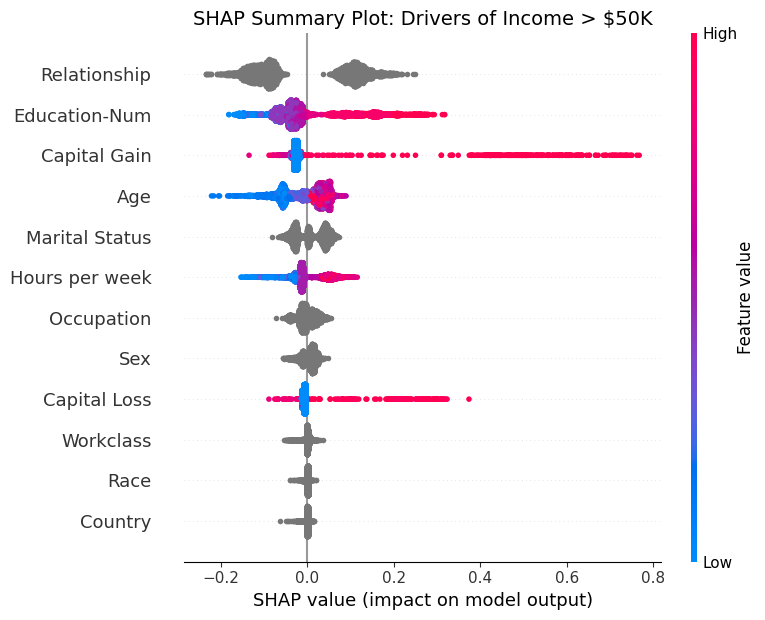

In [4]:
# Initialize the TreeExplainer specifically designed for tree-based models
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for all test samples
shap_values = explainer.shap_values(X_test_enc)

# Handle both SHAP output formats:
# - list of arrays (older API)
# - ndarray with shape (n_samples, n_features, n_classes) (newer API)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

# Optional title (set after summary_plot with show=False if you want it displayed reliably)
plt.title("SHAP Summary Plot: Drivers of Income > $50K", fontsize=14)
shap.summary_plot(shap_values_class1, X_test_disp)

### 3. Top 5 Most Important Features Globally

Based on the SHAP summary plot (ranked from top to bottom), the top 5 global drivers for predicting an income > $50K are:

1. **Relationship** (Categorical)
2. **Education-Num** (Higher numbers strongly increase the probability of higher income)
3. **Capital Gain** (High capital gain heavily pushes predictions towards > $50K)
4. **Age** (Older age generally correlates with higher income predictions)
5. **Marital Status** (Categorical)

### 4. Feature Interactions: Dependence Plots

Dependence plots reveal how a single feature affects the prediction across its entire range, including interactions with other variables (shown by color).

* **Age:** We observe that as age increases from 20 to around 50, its positive impact on earning > $50K grows steadily. After age 60, the effect starts to plateau or decline, reflecting retirement trends.
* **Education-Num:** There is a strong non-linear threshold. Having less than 9-10 years of education negatively impacts the prediction. Passing the threshold of a Bachelor's degree (typically 13 years) sharply increases the SHAP value, strongly pushing the prediction toward > $50K.

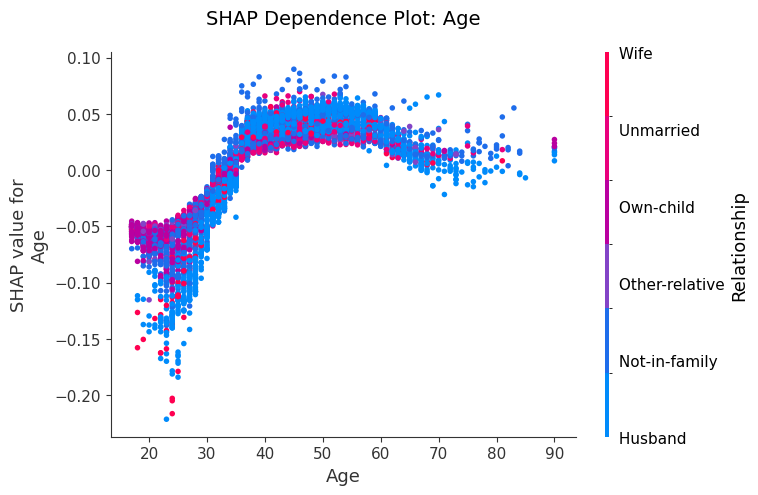

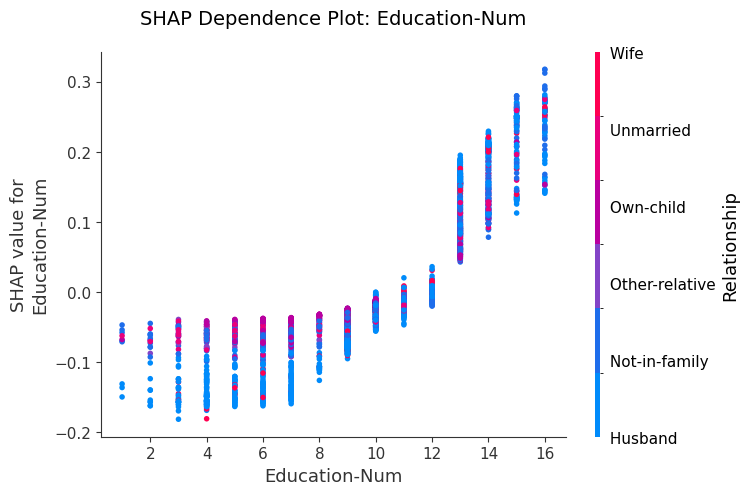

In [5]:
# 1. Dependence plot for 'Age'
# SHAP automatically colors the dots by the feature that interacts most with Age
shap.dependence_plot(
    "Age", 
    shap_values_class1, 
    X_test_disp, 
    show=False
)
plt.title("SHAP Dependence Plot: Age", fontsize=14, y=1.05)
plt.show()

# 2. Dependence plot for 'Education-Num'
shap.dependence_plot(
    "Education-Num", 
    shap_values_class1, 
    X_test_disp, 
    show=False
)
plt.title("SHAP Dependence Plot: Education-Num", fontsize=14, y=1.05);

Based on the generated plots, we can observe clear non-linear relationships that the Random Forest captured:

* **Age:** Being under 30 negatively impacts the probability of earning >$50K. The SHAP value rises sharply and peaks between ages 40 and 50 (prime earning years) before slowly declining as people approach retirement. 
* **Education-Num:** There is a clear "education threshold." Having fewer than 10-12 years of education has a consistent negative impact. However, crossing the 13-year mark (typically equivalent to a Bachelor's degree) causes a massive spike in the SHAP value, strongly driving the prediction towards the >$50K class.
* **Interaction:** SHAP automatically highlighted the `Relationship` feature, showing how family status intertwines with age and education to influence overall income.

### 5. Local Explanations: Individual Predictions

To understand the model's decision-making process on an individual level, we select 3 specific cases (True Positive, True Negative, False Negative) and generate Waterfall plots. These plots show exactly how each feature pushed the prediction away from the baseline (average) value to the final output.


True Positive (Correctly predicted >$50K)
Actual: >$50K | Predicted: >$50K | P(>$50K): 0.654


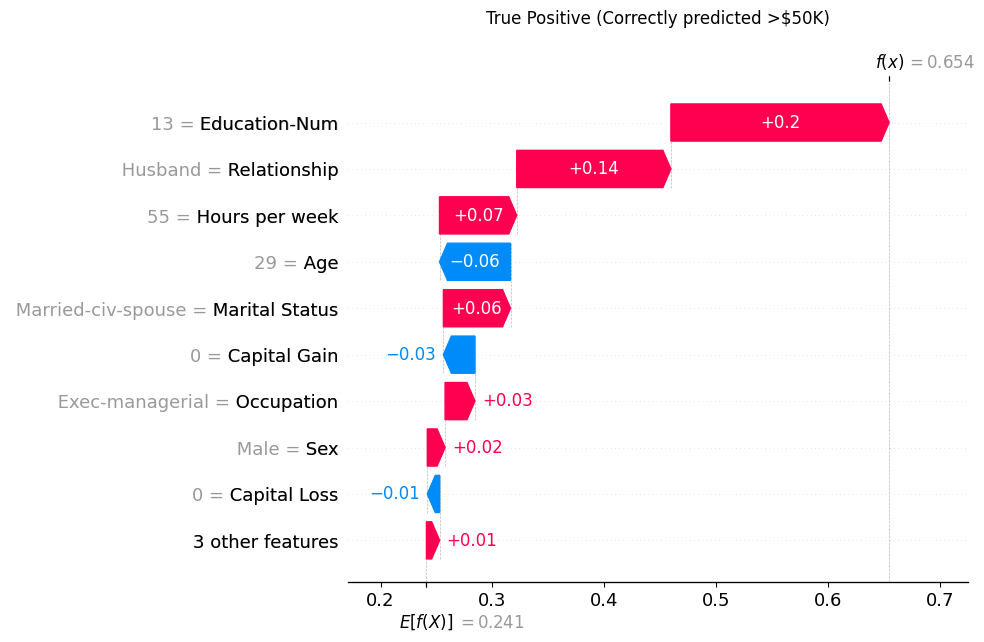


True Negative (Correctly predicted <=$50K)
Actual: <=$50K | Predicted: <=$50K | P(>$50K): 0.014


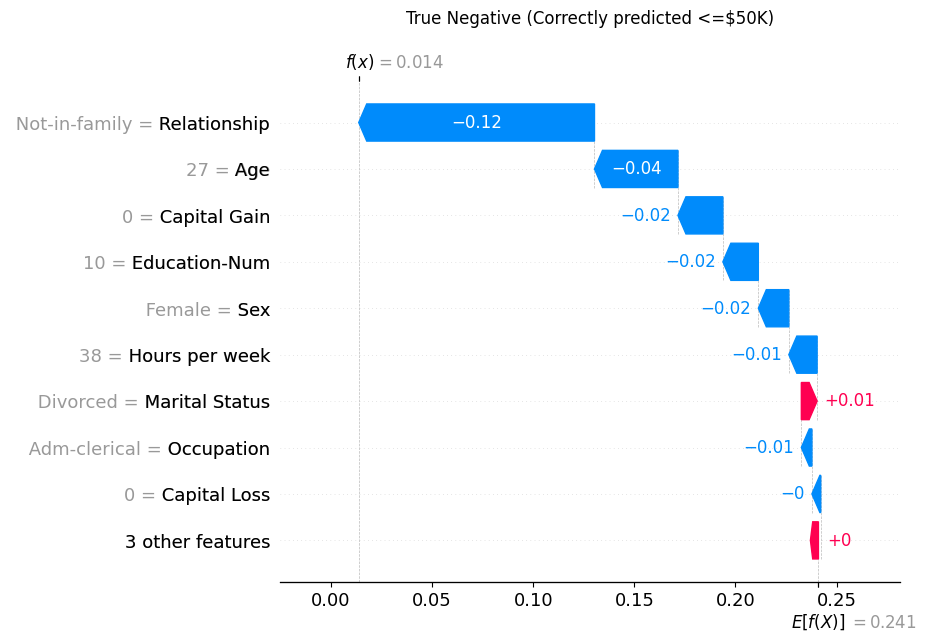


False Negative (Incorrectly predicted <=$50K)
Actual: >$50K | Predicted: <=$50K | P(>$50K): 0.366


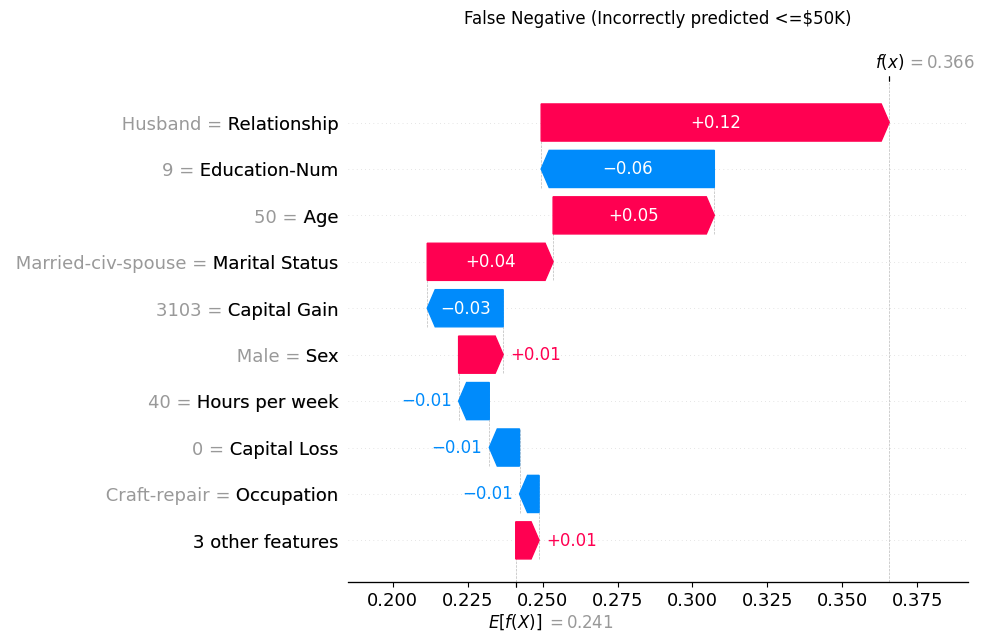

In [ ]:
# 1. Find positional indices for 3 "interesting" individuals
y_test_arr = np.asarray(y_test)  

# True Positive: Actual >50K (1), Predicted >50K (1)
tp_idx = np.where((y_test_arr == 1) & (y_pred == 1))[0][0]

# True Negative: Actual <=50K (0), Predicted <=50K (0)
tn_idx = np.where((y_test_arr == 0) & (y_pred == 0))[0][0]

# False Negative: Actual >50K (1), Predicted <=50K (0)
fn_idx = np.where((y_test_arr == 1) & (y_pred == 0))[0][0]

individuals = [
    (tp_idx, "True Positive (Correctly predicted >$50K)"),
    (tn_idx, "True Negative (Correctly predicted <=$50K)"),
    (fn_idx, "False Negative (Incorrectly predicted <=$50K)")
]

# 2. Generate Waterfall plots for each selected individual
for idx, title in individuals:
    exp = explainer(X_test_enc.iloc[[idx]])
    ind_exp = exp[0, :, 1]
    ind_exp.data = X_test_disp.iloc[idx].values

    actual_label = int(y_test[idx])
    pred_label = int(y_pred[idx])
    pred_prob = rf_model.predict_proba(X_test_enc.iloc[[idx]])[0, 1]

    print(f"\n{title}")
    print(
        f"Actual: {'>$50K' if actual_label == 1 else '<=$50K'} | "
        f"Predicted: {'>$50K' if pred_label == 1 else '<=$50K'} | "
        f"P(>$50K): {pred_prob:.3f}"
    )

    shap.plots.waterfall(ind_exp, max_display=10, show=False)
    plt.title(title, pad=20)
    plt.show()


### 6. Analysis of Local Predictions (Waterfall Plots)

The waterfall plots start from the expected baseline probability of the dataset ($E[f(X)] = 0.241$ or 24.1%) and show how individual features push the final prediction probability ($f(x)$) up or down.

1. **True Positive ($f(x) = 0.654$):** The model correctly predicted an income >$50K. Although the individual's young age (29) negatively impacted the score, having 13 years of education and working 55 hours per week strongly pushed the probability well over the 0.5 threshold.
2. **True Negative ($f(x) = 0.014$):** The model correctly predicted an income <=$50K with high confidence. Features such as being "Not-in-family", young age (27), and lower education (10 years) all worked together to drag the prediction down near zero.
3. **False Negative ($f(x) = 0.366$):** The model failed here, predicting <=$50K for an actual high earner. While the individual's older age (50) and status as a husband added positive value, the model penalized them heavily for having only 9 years of education. This heavy penalty pulled the final probability below the 0.5 decision boundary, resulting in a misclassification.